# Word Rate Plotter
Plots the relative frequency (rate) of words over time from CCAnalysis JSON output files.

**JSON format expected:**
```json
{"total_word_occurrences": 1049088412, "words": [{"word": "fire", "count": 252855133}, ...]}
```

In [29]:
# Install dependencies into your conda environment if needed:
# conda install matplotlib
# or: pip install matplotlib

In [30]:
import json
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [42]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────────

# Map each JSON file to the date it represents.
# Date strings can be any unambiguous format: "2013-01", "2020-06-15", etc.
FILES = {
    "../CCAnalysis/counts_2013_20.json": "2013-01-01",
    "../CCAnalysis/counts_2020_10_20260414_180506.json": "2020-01-01",
}

# Path to a plain-text file of target words to plot (one per line, # = comment)
WORDS_FILE = "target_words.txt"

# Words to explicitly exclude from plotting
FILTERED_WORDS = ["fire", " "]

# ───────────────────────────────────────────────────────────────────────────────

In [43]:
def load_counts(path):
    """Load a CCAnalysis JSON file and return ({word: count}, total_tokens).

    Prefers total_corpus_tokens (raw token count) over total_word_occurrences
    (filtered count) as the normalizer, falling back when the field is absent.
    """
    with open(path) as f:
        data = json.load(f)
    total = data.get("total_corpus_tokens") or data["total_word_occurrences"]
    return {entry["word"]: entry["count"] for entry in data["words"]}, total

def parse_date(s):
    for fmt in ("%Y-%m-%d", "%Y-%m", "%Y"):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    raise ValueError(f"Cannot parse date: {s!r}")

In [44]:
timeline = []
for path, date_str in FILES.items():
    counts, total = load_counts(path)
    timeline.append((parse_date(date_str), counts, total))

timeline.sort(key=lambda x: x[0])
dates = [t for t, _, _ in timeline]
print(f"Loaded {len(timeline)} file(s): {[d.strftime('%Y-%m-%d') for d in dates]}")
for i, (d, counts, total) in enumerate(timeline):
    print(f"  [{i}] {d.strftime('%Y-%m-%d')} — {len(counts)} words, {total:,} total tokens")

Loaded 2 file(s): ['2013-01-01', '2020-01-01']
  [0] 2013-01-01 — 71 words, 1,049,088,412 total tokens
  [1] 2020-01-01 — 71 words, 1,464,352,575 total tokens


In [45]:
words: list[str] = []
with open(WORDS_FILE) as f:
    for line in f:
        if "#" not in line:
            word = line.strip()
            if word and word not in FILTERED_WORDS:
                words.append(word)

print(f"Loaded {len(words)} target words")

Loaded 76 target words


In [46]:
# Install a font that supports emojis
!apt-get install -qq fonts-segoe-ui-emoji

# Clear matplotlib's font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print("Matplotlib font cache cleared.")

zsh:1: command not found: apt-get
Matplotlib font cache cleared.


After running the above cells, you will need to re-run the plotting cell (`e7h66jgJUWqD`) for the changes to take effect and display the emojis correctly.

In [47]:
import platform

# Use a system font that supports emoji glyphs.
# On macOS the built-in "Apple Color Emoji" covers most cases.
# On Linux with conda, install fonts-noto-color-emoji via your package manager.
if platform.system() == "Darwin":
    emoji_font = "Apple Color Emoji"
elif platform.system() == "Windows":
    emoji_font = "Segoe UI Emoji"
else:
    emoji_font = "Noto Color Emoji"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [emoji_font, "DejaVu Sans"]

/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_71703/2208850371.py:18: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_71703/2208850371.py:18: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_71703/2208850371.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/dexter/anaconda3/envs/cs224n/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dexter/anaconda3/envs/cs224n/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_

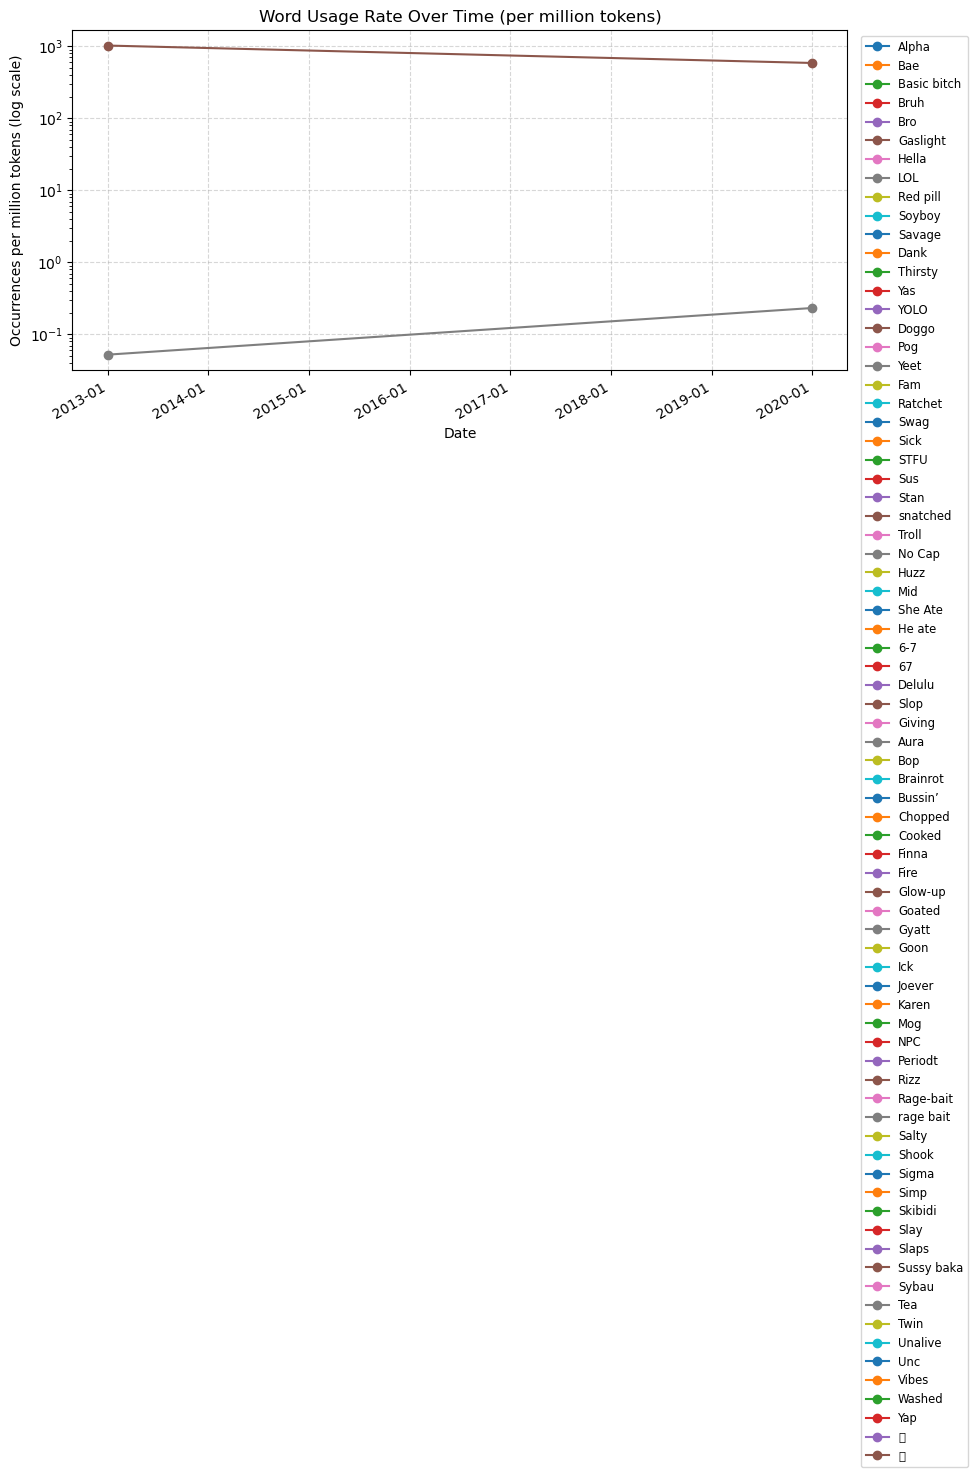

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))

for word in words:
    rates = [
        counts_map.get(word, 0) / total * 1_000_000
        for _, counts_map, total in timeline
    ]
    ax.plot(dates, rates, marker="o", label=word)

ax.set_title("Word Usage Rate Over Time (per million tokens)")
ax.set_xlabel("Date")
ax.set_ylabel("Occurrences per million tokens (log scale)")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [49]:
# ── BAR CHART: log₂ ratio of last vs first dump rate ──────────────────────────
# +1 = word doubled in frequency, −1 = halved.
# Sorted so the words that grew most are at the top.
# Words missing from either dump are excluded.

changes = []
for word in words:
    r0 = first_counts.get(word, 0) / first_total * 1_000_000
    r1 = last_counts.get(word, 0)  / last_total  * 1_000_000
    if r0 > 0 and r1 > 0:
        changes.append((word, np.log2(r1 / r0)))

changes.sort(key=lambda x: x[1])
bar_labels, ratios = zip(*changes)
colors = ["#d73027" if r < 0 else "#1a9850" for r in ratios]

fig_h = max(6, len(changes) * 0.28)
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(range(len(changes)), ratios, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(range(len(changes)))
ax.set_yticklabels(bar_labels, fontsize=8)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel(
    f"log₂(rate {last_date.strftime('%Y')} / rate {first_date.strftime('%Y')})"
    "\n+1 = doubled   0 = unchanged   −1 = halved",
    fontsize=10,
)
ax.set_title(
    f"Change in relative word frequency\n{first_date.strftime('%Y-%m-%d')} → {last_date.strftime('%Y-%m-%d')}",
    fontsize=12,
)
ax.grid(axis="x", linestyle="--", alpha=0.45)
plt.tight_layout()
plt.show()

n_up   = sum(1 for _, r in changes if r > 0)
n_down = sum(1 for _, r in changes if r < 0)
print(f"{n_up} words increased, {n_down} decreased")

NameError: name 'first_counts' is not defined

In [ ]:
# ── SCATTER PLOT: first dump rate vs last dump rate ────────────────────────────
# Each word is a point. Words above the diagonal increased in relative frequency.
# Both axes are log-scale so words at very different frequencies are still visible.

import numpy as np

first_date, first_counts, first_total = timeline[0]
last_date,  last_counts,  last_total  = timeline[-1]

fig, ax = plt.subplots(figsize=(8, 8))

rates_first, rates_last, labels = [], [], []
for word in words:
    r0 = first_counts.get(word, 0) / first_total * 1_000_000
    r1 = last_counts.get(word, 0)  / last_total  * 1_000_000
    if r0 > 0 and r1 > 0:
        rates_first.append(r0)
        rates_last.append(r1)
        labels.append(word)

ax.scatter(rates_first, rates_last, s=25, alpha=0.7, zorder=3)

for x, y, w in zip(rates_first, rates_last, labels):
    ax.annotate(w, (x, y), fontsize=6.5, alpha=0.85,
                xytext=(3, 3), textcoords="offset points")

# Diagonal reference line (no change)
all_rates = rates_first + rates_last
lo, hi = min(all_rates) * 0.7, max(all_rates) * 1.4
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.9, alpha=0.45, label="no change")
ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.04, color="green")
ax.fill_between([lo, hi], [lo, lo], [lo, hi], alpha=0.04, color="red")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f"Rate per million tokens  ({first_date.strftime('%Y-%m-%d')})", fontsize=11)
ax.set_ylabel(f"Rate per million tokens  ({last_date.strftime('%Y-%m-%d')})",  fontsize=11)
ax.set_title("Word frequency: first dump vs latest dump\n(above diagonal = increased, below = decreased)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4, which="both")
plt.tight_layout()
plt.show()